# Which bootstrap should I use?

There is no universally best bootstrap. The right method depends on what you are willing to assume about the process that generated your data. The way to see that is to take series whose dependence structure we set ourselves, then watch each method succeed or fail against it.

The workhorse here is a stationary AR(1) process, `x[t] = phi * x[t-1] + e[t]` with `phi = 0.5` and unit-variance noise. Its theoretical autocorrelation is `rho_k = phi**k` and the long-run variance of the sample mean is `sigma_eps**2 / (1 - phi)**2 / n`, so we always have a true value to compare the bootstrap against.

The recipes:

1. IID resampling destroys autocorrelation.
2. Block methods bias the AR coefficient downward, and tapering recenters it.
3. Block length is a bias-variance knob.
4. Model-based bootstraps win when correctly specified and fail when misspecified.
5. `diagnose()` as a closing advisor.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## Helpers: DGPs, an OLS lag-1 estimator, and a coverage Monte-Carlo

The pieces every recipe below leans on, all defined inline.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from tsbootstrap import (
    AR,
    IID,
    CircularBlock,
    MovingBlock,
    ResidualBootstrap,
    SieveAR,
    StationaryBlock,
    TaperedBlock,
    bootstrap,
    diagnose,
)
from tsbootstrap.block.pwsd import optimal_block_length

PHI = 0.5


def ar1(n, phi=PHI, rng=None):
    """Stationary AR(1) with unit-variance Gaussian noise, started at 0."""
    rng = np.random.default_rng() if rng is None else rng
    x = np.zeros(n)
    e = rng.standard_normal(n)
    for t in range(1, n):
        x[t] = phi * x[t - 1] + e[t]
    return x


def ar1_coef(series):
    """OLS lag-1 autoregression coefficient (the estimated phi)."""
    s = np.asarray(series, dtype=float)
    a, b = s[:-1], s[1:]
    return float(np.dot(a, b) / np.dot(a, a))


def sample_acf(series, max_lag):
    """Sample autocorrelation rho_k for k = 0..max_lag."""
    s = np.asarray(series, dtype=float)
    s = s - s.mean()
    denom = np.dot(s, s)
    return np.array([1.0 if k == 0 else np.dot(s[:-k], s[k:]) / denom for k in range(max_lag + 1)])

## Recipe 1: IID resampling destroys autocorrelation

Plain i.i.d. resampling shuffles observations independently, so any ordering information, and therefore all serial dependence, is gone. We can see this directly: for an AR(1) the true autocorrelation decays as `phi**k`, the sample ACF tracks it, but the ACF averaged over `IID()` replicates collapses to roughly zero at every positive lag. IID manufactures white noise.

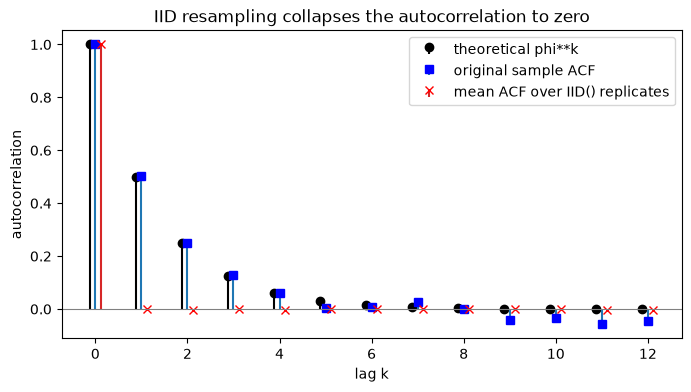

original lag-1 ACF: 0.503  (truth 0.500)
IID mean lag-1 ACF: 0.000  (collapsed toward 0)


In [3]:
rng = np.random.default_rng(0)
n = 1000
x = ar1(n, PHI, rng)
MAX_LAG = 12

lags = np.arange(MAX_LAG + 1)
theoretical_acf = PHI**lags
original_acf = sample_acf(x, MAX_LAG)

iid_res = bootstrap(x, method=IID(), n_bootstraps=300, random_state=1)
iid_acf = np.mean([sample_acf(v, MAX_LAG) for v in iid_res.values()], axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(
    lags - 0.12,
    theoretical_acf,
    linefmt="black",
    markerfmt="ko",
    basefmt=" ",
    label="theoretical phi**k",
)
ax.stem(
    lags, original_acf, linefmt="tab:blue", markerfmt="bs", basefmt=" ", label="original sample ACF"
)
ax.stem(
    lags + 0.12,
    iid_acf,
    linefmt="tab:red",
    markerfmt="rx",
    basefmt=" ",
    label="mean ACF over IID() replicates",
)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("lag k")
ax.set_ylabel("autocorrelation")
ax.set_title("IID resampling collapses the autocorrelation to zero")
ax.legend()
plt.show()

print(f"original lag-1 ACF: {original_acf[1]:.3f}  (truth {PHI:.3f})")
print(f"IID mean lag-1 ACF: {iid_acf[1]:.3f}  (collapsed toward 0)")

The red marks sit on the zero line: the IID bootstrap throws away exactly the structure a time-series bootstrap is supposed to preserve. Use it only when you have already decided the data are independent.

## Recipe 2: block edge effects and the downward AR-coefficient bias

Block bootstraps resample contiguous blocks to keep local dependence. But the joins between blocks break dependence at the seams, which biases the estimated AR coefficient downward. We estimate the lag-1 coefficient on every replicate for four block methods and compare the distributions to the original-sample estimate. The tapered block down-weights block edges, so it recenters closer to the truth.

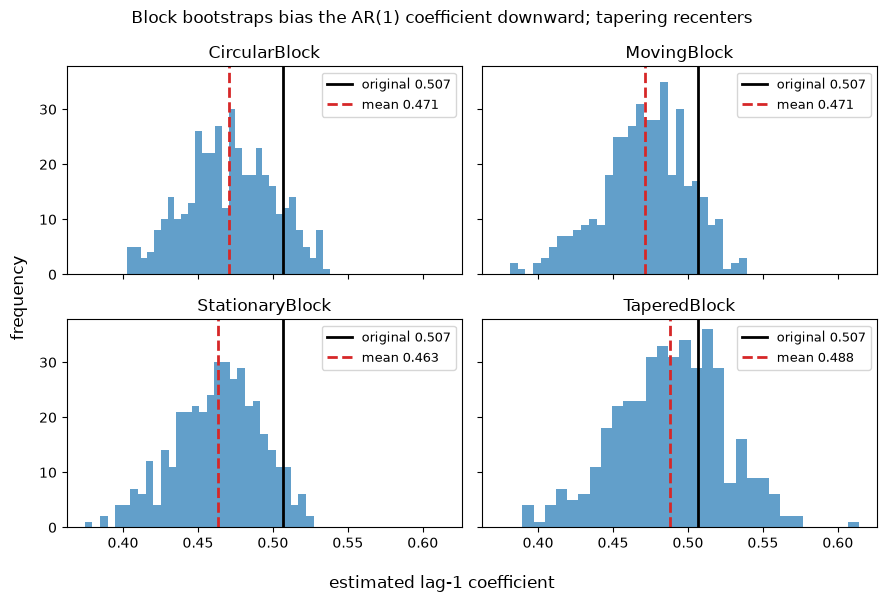

CircularBlock    mean coef = 0.4709  (original 0.5067)
MovingBlock      mean coef = 0.4713  (original 0.5067)
StationaryBlock  mean coef = 0.4634  (original 0.5067)
TaperedBlock     mean coef = 0.4882  (original 0.5067)


In [4]:
orig_coef = ar1_coef(x)
B = 400

block_specs = {
    "CircularBlock": CircularBlock(block_length="auto"),
    "MovingBlock": MovingBlock(block_length="auto"),
    "StationaryBlock": StationaryBlock(avg_block_length="auto"),
    "TaperedBlock": TaperedBlock(block_length="auto"),
}

coef_draws = {}
for name, spec in block_specs.items():
    res = bootstrap(x, method=spec, n_bootstraps=B, random_state=2)
    coef_draws[name] = np.array([ar1_coef(v) for v in res.values()])

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True)
for ax, (name, draws) in zip(axes.ravel(), coef_draws.items()):
    ax.hist(draws, bins=30, color="tab:blue", alpha=0.7)
    ax.axvline(orig_coef, color="black", lw=2, label=f"original {orig_coef:.3f}")
    ax.axvline(draws.mean(), color="tab:red", lw=2, ls="--", label=f"mean {draws.mean():.3f}")
    ax.set_title(name)
    ax.legend(fontsize=9)
fig.suptitle("Block bootstraps bias the AR(1) coefficient downward; tapering recenters")
fig.supxlabel("estimated lag-1 coefficient")
fig.supylabel("frequency")
fig.tight_layout()
plt.show()

for name, draws in coef_draws.items():
    print(f"{name:16s} mean coef = {draws.mean():.4f}  (original {orig_coef:.4f})")

Every block method sits to the left of the original estimate: the seams cost dependence. The tapered block is closest to the truth because its window weights down the very edges that cause the bias.

The bias has a second source: where in the series each method samples. The in-bag counts (how often each original index appears across replicates) reveal it. The moving block, whose blocks must start in `[0, n - L]`, under-samples the two ends; the circular block wraps around, so its coverage is flat.

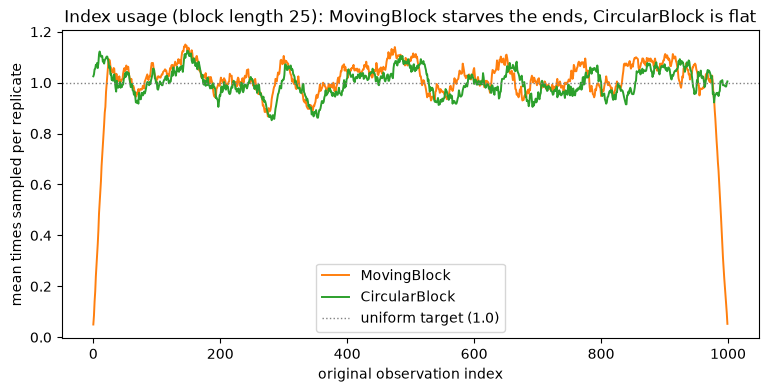

MovingBlock  edge mean usage 0.574  vs middle 1.076
CircularBlock edge mean usage 1.030  vs middle 1.074


In [5]:
L = 25
mb = bootstrap(x, method=MovingBlock(block_length=L), n_bootstraps=B, random_state=3)
cb = bootstrap(x, method=CircularBlock(block_length=L), n_bootstraps=B, random_state=3)

mb_usage = mb.inbag_counts().mean(axis=0)
cb_usage = cb.inbag_counts().mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mb_usage, color="tab:orange", lw=1.4, label="MovingBlock")
ax.plot(cb_usage, color="tab:green", lw=1.4, label="CircularBlock")
ax.axhline(1.0, color="gray", ls=":", lw=1, label="uniform target (1.0)")
ax.set_xlabel("original observation index")
ax.set_ylabel("mean times sampled per replicate")
ax.set_title(f"Index usage (block length {L}): MovingBlock starves the ends, CircularBlock is flat")
ax.legend()
plt.show()

edge = list(range(L)) + list(range(n - L, n))
mid = list(range(n // 2 - L, n // 2 + L))
print(
    f"MovingBlock  edge mean usage {mb_usage[edge].mean():.3f}  vs middle {mb_usage[mid].mean():.3f}"
)
print(
    f"CircularBlock edge mean usage {cb_usage[edge].mean():.3f}  vs middle {cb_usage[mid].mean():.3f}"
)

The moving block visibly droops at both ends: the first and last observations can only appear in a few blocks, so they are under-represented. The circular block's wrap-around fixes this, at the cost of joining the end of the series back to its start.

## Recipe 3: block length is a bias-variance knob

The block length controls how much dependence the bootstrap preserves. Too short and the replicates look i.i.d., so the variance of the sample mean is underestimated. Too long and there are too few independent blocks, so the estimate is noisy. We sweep the block length and compare the bootstrap estimate of `Var(mean)` to the known long-run value.

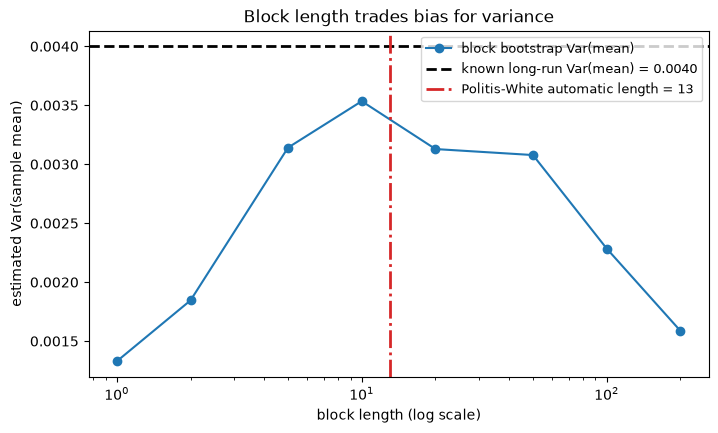

block length    1: Var(mean) = 0.00133  (truth 0.00400)
block length    2: Var(mean) = 0.00185  (truth 0.00400)
block length    5: Var(mean) = 0.00314  (truth 0.00400)
block length   10: Var(mean) = 0.00353  (truth 0.00400)
block length   20: Var(mean) = 0.00313  (truth 0.00400)
block length   50: Var(mean) = 0.00308  (truth 0.00400)
block length  100: Var(mean) = 0.00228  (truth 0.00400)
block length  200: Var(mean) = 0.00159  (truth 0.00400)


In [6]:
sigma_eps2 = 1.0
true_var_mean = sigma_eps2 / (1 - PHI) ** 2 / n

grid = [1, 2, 5, 10, 20, 50, 100, 200]
var_estimates = []
for bl in grid:
    res = bootstrap(x, method=MovingBlock(block_length=bl), n_bootstraps=B, random_state=4)
    var_estimates.append(float(res.values().mean(axis=1).var()))

auto_len = optimal_block_length(x.reshape(-1, 1), kind="circular")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(grid, var_estimates, "o-", color="tab:blue", label="block bootstrap Var(mean)")
ax.axhline(
    true_var_mean,
    color="black",
    lw=2,
    ls="--",
    label=f"known long-run Var(mean) = {true_var_mean:.4f}",
)
ax.axvline(
    auto_len, color="tab:red", lw=2, ls="-.", label=f"Politis-White automatic length = {auto_len}"
)
ax.set_xscale("log")
ax.set_xlabel("block length (log scale)")
ax.set_ylabel("estimated Var(sample mean)")
ax.set_title("Block length trades bias for variance")
ax.legend(fontsize=9)
plt.show()

for bl, v in zip(grid, var_estimates):
    print(f"block length {bl:4d}: Var(mean) = {v:.5f}  (truth {true_var_mean:.5f})")

Short blocks sit well below the dashed truth line: they behave almost like IID and miss the positive dependence that inflates the variance of the mean. As the block grows the estimate climbs toward the truth, then becomes erratic once the blocks are so long that only a handful fit in the series. The Politis-White automatic length lands in the useful middle region.

One caveat: that automatic length is optimal for the variance-of-the-mean target. It is not guaranteed optimal for every statistic you might bootstrap; a different functional can prefer a different block length.

## Recipe 4: model-based bootstraps under misspecification

Model-based bootstraps (`ResidualBootstrap`, `SieveAR`) fit a parametric model, then resample its innovations. When the model is correct this is efficient: tight intervals at near-nominal coverage. When the model is wrong, the bootstrap inherits the model's error.

We run a small coverage Monte-Carlo for a 95% interval on the sample mean. The correct process is the AR(1) we have used throughout. The misspecified process is an AR(3) with real dependence at lags 2 and 3; we deliberately fit a fixed-order AR(1) residual bootstrap to it. `SieveAR` selects its order from the data, and `MovingBlock` assumes no model at all, so both should stay closer to nominal.

In [7]:
def coverage_mc(dgp, method, true_mean, M=150, B_inner=99, n_obs=600, alpha=0.05, seed=0):
    """Fraction of (1-alpha) percentile intervals for the mean that cover true_mean, and mean width."""
    rng = np.random.default_rng(seed)
    covered, widths = 0, []
    for _ in range(M):
        series = dgp(n_obs, rng)
        res = bootstrap(
            series,
            method=method,
            n_bootstraps=B_inner,
            random_state=int(rng.integers(1_000_000_000)),
        )
        if len(res) == 0:  # preparation failed (e.g. non-stationary fit)
            continue
        means = res.values().mean(axis=1)
        lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
        widths.append(hi - lo)
        covered += int(lo <= true_mean <= hi)
    return covered / M, float(np.mean(widths))


def dgp_correct(n_obs, rng):
    """AR(1), phi=0.5, true mean 0. Matches ResidualBootstrap(AR(1))."""
    return ar1(n_obs, PHI, rng)


def dgp_misspecified(n_obs, rng):
    """AR(3) with real lag-2 and lag-3 dependence, true mean 0. An AR(1) fit cannot see it."""
    phi = (0.3, 0.2, 0.35)
    burn = 100
    z = np.zeros(n_obs + burn)
    e = rng.standard_normal(n_obs + burn)
    for t in range(3, n_obs + burn):
        z[t] = phi[0] * z[t - 1] + phi[1] * z[t - 2] + phi[2] * z[t - 3] + e[t]
    return z[burn:]

In [8]:
methods = {
    "ResidualBootstrap(AR(1))": ResidualBootstrap(model=AR(order=1)),
    "SieveAR (order from data)": SieveAR(),
    "MovingBlock (no model)": MovingBlock(block_length="auto"),
}

rows = []
for name, spec in methods.items():
    c_ok, w_ok = coverage_mc(dgp_correct, spec, true_mean=0.0, seed=10)
    c_bad, w_bad = coverage_mc(dgp_misspecified, spec, true_mean=0.0, seed=20)
    rows.append((name, c_ok, w_ok, c_bad, w_bad))

header = f"{'method':26s} {'cov(correct)':>13s} {'width':>8s} {'cov(misspec)':>13s} {'width':>8s}"
print(header)
print("-" * len(header))
for name, c_ok, w_ok, c_bad, w_bad in rows:
    print(f"{name:26s} {c_ok:13.2f} {w_ok:8.3f} {c_bad:13.2f} {w_bad:8.3f}")
print("\nnominal coverage = 0.95")

method                      cov(correct)    width  cov(misspec)    width
------------------------------------------------------------------------
ResidualBootstrap(AR(1))            0.91    0.305          0.52    0.479
SieveAR (order from data)           0.91    0.305          0.87    0.947
MovingBlock (no model)              0.86    0.282          0.83    0.804

nominal coverage = 0.95


On the correct AR(1) process all three methods land near nominal, and the model-based pair give the tightest intervals: when the model is right, modelling pays off.

On the misspecified AR(3) the fixed-order `ResidualBootstrap(AR(1))` collapses well below nominal. It imposes an AR(1) structure that cannot represent the lag-2 and lag-3 dependence, so its intervals are too narrow for the true variability of the mean. `SieveAR` recovers most of the coverage because it selects the AR order from the data, and the assumption-free `MovingBlock` stays robust. The failure here is the fixed, wrong model, not model-based bootstraps in general; a block method is the more robust choice when you are unsure of the structure.

## Capstone: `diagnose()` as an advisor

Choosing by hand requires knowing the truth, which in practice you do not. `diagnose()` reads the data and recommends method specifications from what it measures. We run it on four series with very different structure.

In [9]:
rng = np.random.default_rng(7)
series_ar1 = ar1(600, PHI, rng)
series_rw = np.cumsum(rng.standard_normal(600))  # random walk (unit root)
series_iid = rng.standard_normal(600)  # near-i.i.d.
series_var = np.column_stack([ar1(600, 0.6, rng), ar1(600, 0.6, rng)])  # bivariate

examples = {
    "AR(1) stationary": series_ar1,
    "random walk": series_rw,
    "near-i.i.d.": series_iid,
    "bivariate (VAR-like)": series_var,
}
for name, s in examples.items():
    d = diagnose(s)
    print(f"{name:22s} -> {d.recommended_methods}")

AR(1) stationary       -> ('StationaryBlock', 'MovingBlock', 'SieveAR')


random walk            -> ('ResidualBootstrap(model=ARIMA(...))', 'SieveAR')
near-i.i.d.            -> ('IID', 'MovingBlock')
bivariate (VAR-like)   -> ('ResidualBootstrap(model=VAR(...))', 'StationaryBlock', 'MovingBlock', 'SieveAR')


Read these carefully. `diagnose()` inspects two things: serial dependence (lag-1 autocorrelation) and stationarity (an augmented Dickey-Fuller test). It recommends specs from those signals: block methods and the sieve for stationary dependence, an integrated model or the sieve for a unit root, IID when dependence is weak, and a VAR for multivariate input. It does **not** detect volatility clustering, regime shifts, or seasonality, and it is deliberately extensible rather than exhaustive. Treat it as a fast, transparent starting point, not an oracle.

No peer bootstrap or uncertainty library (MAPIE, darts, arch) ships a from-the-data programmatic recommender; tsbootstrap provides `diagnose()` for this.

### The thesis

There is no universally best bootstrap. IID is fine only without dependence. Block methods are robust but bias the dependence and need a length. Model-based methods are efficient when correct and fail when misspecified. The right choice depends on what you are willing to assume about the data-generating process, and `diagnose()` is there to help you make that assumption explicit.